<a href="https://colab.research.google.com/github/frank-morales2020/MLxDL/blob/main/FIFA_World_Cup_2026_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://medium.com/ai-simplified-in-plain-english/the-h2e-framework-engineering-accountability-into-the-industrial-ai-era-7019524e9713

## CASE0

In [1]:
import random
import json
import time
from google import genai
from google.genai import types

# --- GEMINI CLIENT SETUP (USING REQUESTED ID) ---
client = None
REQUESTED_GEMINI_MODEL_ID = 'gemini-3-pro-preview'

try:
    # Assuming userdata is available in your environment (e.g., Google Colab)
    from google.colab import userdata
    GOOGLE_API_KEY = userdata.get('GEMINI')
    client = genai.Client(api_key=GOOGLE_API_KEY)
    print(f"Gemini client configured for **{REQUESTED_GEMINI_MODEL_ID}**.")
except Exception:
    print("Configuration Error: Gemini client could not be initialized. Check your API key.")

# --- 48-TEAM DATASET ---
teams_data = {
    "Group A": [{"name": "Mexico", "elo": 1820}, {"name": "South Africa", "elo": 1610}, {"name": "South Korea", "elo": 1750}, {"name": "Denmark", "elo": 1780}],
    "Group B": [{"name": "Canada", "elo": 1720}, {"name": "Italy", "elo": 1890}, {"name": "Qatar", "elo": 1640}, {"name": "Switzerland", "elo": 1795}],
    "Group C": [{"name": "Brazil", "elo": 1980}, {"name": "Morocco", "elo": 1860}, {"name": "Haiti", "elo": 1450}, {"name": "Scotland", "elo": 1690}],
    "Group D": [{"name": "USA", "elo": 1810}, {"name": "Paraguay", "elo": 1675}, {"name": "Australia", "elo": 1730}, {"name": "Turkey", "elo": 1745}],
    "Group E": [{"name": "Germany", "elo": 1910}, {"name": "Curacao", "elo": 1480}, {"name": "Ivory Coast", "elo": 1705}, {"name": "Ecuador", "elo": 1765}],
    "Group F": [{"name": "Netherlands", "elo": 1930}, {"name": "Japan", "elo": 1805}, {"name": "Ukraine", "elo": 1735}, {"name": "Tunisia", "elo": 1655}],
    "Group G": [{"name": "Belgium", "elo": 1895}, {"name": "Egypt", "elo": 1715}, {"name": "Iran", "elo": 1770}, {"name": "New Zealand", "elo": 1420}],
    "Group H": [{"name": "Spain", "elo": 2040}, {"name": "Cape Verde", "elo": 1585}, {"name": "Saudi Arabia", "elo": 1605}, {"name": "Uruguay", "elo": 1850}],
    "Group I": [{"name": "France", "elo": 2010}, {"name": "Senegal", "elo": 1790}, {"name": "Iraq", "elo": 1615}, {"name": "Norway", "elo": 1725}],
    "Group J": [{"name": "Argentina", "elo": 2035}, {"name": "Algeria", "elo": 1710}, {"name": "Austria", "elo": 1755}, {"name": "Jordan", "elo": 1560}],
    "Group K": [{"name": "Portugal", "elo": 1960}, {"name": "Jamaica", "elo": 1570}, {"name": "Uzbekistan", "elo": 1660}, {"name": "Colombia", "elo": 1845}],
    "Group L": [{"name": "England", "elo": 1995}, {"name": "Croatia", "elo": 1885}, {"name": "Ghana", "elo": 1555}, {"name": "Panama", "elo": 1700}]
}

# --- MATCH ENGINE ---
def simulate_match(team_a, team_b, is_knockout=False):
    prompt = f"""
    Act as a FIFA World Cup Match Predictor.
    Match: {team_a['name']} (ELO: {team_a['elo']}) vs {team_b['name']} (ELO: {team_b['elo']}).
    Context: 2026 World Cup conditions.
    Rules:
    - Output realistic scores.
    - If 'is_knockout' is true, there must be a winner (simulate extra time/penalties if score is draw).
    - Return JSON: {{"score_a": int, "score_b": int, "winner_name": "string"}}
    """

    try:
        response = client.models.generate_content(
            model=REQUESTED_GEMINI_MODEL_ID,
            contents=prompt,
            config=types.GenerateContentConfig(response_mime_type="application/json")
        )
        return json.loads(response.text)
    except Exception as e:
        # Fallback logic if API fails or quota hit
        s_a = 1 if team_a['elo'] > team_b['elo'] else 0
        s_b = 0 if s_a == 1 else 1
        return {"score_a": s_a, "score_b": s_b, "winner_name": team_a['name'] if s_a > s_b else team_b['name']}

# --- TOURNAMENT EXECUTION ---
print("\n⚽ SIMULATING WORLD CUP 2026 ⚽")
all_group_results = {}
third_place_pool = []

# 1. Group Stage
for group, teams in teams_data.items():
    print(f"Simulating {group}...")
    table = {t['name']: {'pts': 0, 'gd': 0, 'data': t} for t in teams}
    for i in range(len(teams)):
        for j in range(i + 1, len(teams)):
            res = simulate_match(teams[i], teams[j])
            table[teams[i]['name']]['gd'] += (res['score_a'] - res['score_b'])
            table[teams[j]['name']]['gd'] += (res['score_b'] - res['score_a'])
            if res['score_a'] > res['score_b']: table[teams[i]['name']]['pts'] += 3
            elif res['score_b'] > res['score_a']: table[teams[j]['name']]['pts'] += 3
            else:
                table[teams[i]['name']]['pts'] += 1
                table[teams[j]['name']]['pts'] += 1

    sorted_table = sorted(table.items(), key=lambda x: (x[1]['pts'], x[1]['gd']), reverse=True)
    all_group_results[group] = sorted_table
    third_place_pool.append(sorted_table[2][1]) # Add 3rd place team to pool

# 2. Advanced Qualification Logic
knockout_roster = []
for group in all_group_results.values():
    knockout_roster.append(group[0][1]['data']) # Winners
    knockout_roster.append(group[1][1]['data']) # Runners-up

# Rank and take top 8 third-place teams
best_8_thirds = sorted(third_place_pool, key=lambda x: (x['pts'], x['gd']), reverse=True)[:8]
knockout_roster.extend([t['data'] for t in best_8_thirds])

# 3. Knockout Rounds
current_teams = knockout_roster
stages = ["Round of 32", "Round of 16", "Quarter-Finals", "Semi-Finals", "Final"]

for stage in stages:
    print(f"\n--- {stage.upper()} ---")
    winners = []
    for i in range(0, len(current_teams), 2):
        t1, t2 = current_teams[i], current_teams[i+1]
        res = simulate_match(t1, t2, is_knockout=True)
        winner = t1 if res['winner_name'] == t1['name'] else t2
        print(f"{t1['name']} {res['score_a']} - {res['score_b']} {t2['name']} | Winner: {winner['name']}")
        winners.append(winner)
    current_teams = winners
    if len(current_teams) == 1:
        print(f"\n🏆 WORLD CHAMPION 2026: {current_teams[0]['name'].upper()} 🏆")
        break

Gemini client configured for **gemini-3-pro-preview**.

⚽ SIMULATING WORLD CUP 2026 ⚽
Simulating Group A...
Simulating Group B...
Simulating Group C...
Simulating Group D...
Simulating Group E...
Simulating Group F...
Simulating Group G...
Simulating Group H...
Simulating Group I...
Simulating Group J...
Simulating Group K...
Simulating Group L...

--- ROUND OF 32 ---
Mexico 2 - 1 Denmark | Winner: Mexico
Italy 2 - 1 Switzerland | Winner: Italy
Brazil 2 - 1 Morocco | Winner: Brazil
USA 2 - 1 Turkey | Winner: USA
Germany 2 - 1 Ecuador | Winner: Germany
Netherlands 2 - 1 Japan | Winner: Netherlands
Belgium 2 - 1 Iran | Winner: Belgium
Spain 2 - 1 Uruguay | Winner: Spain
France 2 - 0 Senegal | Winner: France
Argentina 2 - 0 Austria | Winner: Argentina
Portugal 2 - 1 Colombia | Winner: Portugal
England 2 - 1 Croatia | Winner: England
Canada 2 - 1 Egypt | Winner: Canada
South Korea 2 - 1 Australia | Winner: South Korea
Ivory Coast 2 - 1 Scotland | Winner: Ivory Coast
Ukraine 1 - 2 Norway | 

## H2E Engine: Historical H2H & Penalty Integration

https://medium.com/ai-simplified-in-plain-english/the-h2e-framework-engineering-accountability-into-the-industrial-ai-era-7019524e9713

In [2]:
import numpy as np
import json
import random
import time
import math
from google import genai
from google.genai import types

# --- 1. CORE SETUP & GEMINI 3 CONFIGURATION ---
MODEL_NAME = "gemini-3-flash-preview"
try:
    from google.colab import userdata
    client = genai.Client(api_key=userdata.get('GEMINI'))
    print(f"✅ H2E System: Initialized for **{MODEL_NAME}** with thinking capabilities")

    # Test the connection
    test_response = client.models.generate_content(
        model=MODEL_NAME,
        contents="Return JSON: {'test': 'success'}",
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            temperature=1.0
        )
    )
    print(f"✅ Gemini connection successful")

except Exception as e:
    print(f"❌ FATAL ERROR: {e}")
    print("Cannot run simulation without Gemini API")
    exit()

def get_thinking_config(level):
    """
    Returns a Gemini 3 config with thinking enabled.
    Levels: 'minimal', 'low', 'medium', 'high'
    """
    return types.GenerateContentConfig(
        thinking_config=types.ThinkingConfig(
            include_thoughts=True,
            thinking_level=level
        ),
        temperature=1.0,
        response_mime_type="application/json"
    )

# --- H2E FRAMEWORK SETTINGS ---
INTENT_GAIN = 12.5
SROI_THRESHOLD = 0.9583

# --- 2. THE LEGACY DNA: COMPREHENSIVE H2H DATABASE ---
H2H_DATA = {
    "Brazil_Argentina": [46, 26, 41], "Germany_Italy": [9, 11, 15], "Spain_Italy": [13, 16, 11],
    "England_Germany": [14, 6, 13], "France_Brazil": [6, 4, 7], "Netherlands_Germany": [12, 17, 16],
    "Argentina_France": [6, 3, 3], "Portugal_Spain": [6, 17, 18], "Uruguay_Brazil": [21, 17, 38],
    "Mexico_USA": [36, 17, 24], "Japan_South Korea": [16, 23, 42], "Morocco_Senegal": [13, 7, 8],
    "England_Croatia": [6, 2, 3], "Belgium_Netherlands": [41, 31, 56], "USA_Canada": [17, 11, 10],
    "Egypt_Algeria": [7, 11, 10], "Ghana_Ivory Coast": [12, 8, 11], "Denmark_Norway": [54, 14, 21],
    "Australia_New Zealand": [42, 11, 13], "Turkey_Switzerland": [8, 3, 4], "Ukraine_Poland": [3, 2, 4],
    "Colombia_Ecuador": [23, 13, 13], "Saudi Arabia_Iraq": [11, 10, 18], "DEFAULT": [1, 1, 1]
}

# --- 3. ELO DATABASE (48 TEAMS) ---
teams_elo = {
    "Spain": 2040, "Argentina": 2035, "France": 2010, "England": 1995, "Brazil": 1980,
    "Portugal": 1960, "Netherlands": 1930, "Germany": 1910, "Italy": 1890, "Belgium": 1895,
    "Morocco": 1860, "Uruguay": 1850, "Colombia": 1845, "Mexico": 1820, "USA": 1810,
    "Japan": 1805, "Switzerland": 1795, "Senegal": 1790, "Denmark": 1780, "Iran": 1770,
    "Ecuador": 1765, "Austria": 1755, "South Korea": 1750, "Turkey": 1745, "Ukraine": 1735,
    "Australia": 1730, "Norway": 1725, "Canada": 1720, "Egypt": 1715, "Algeria": 1710,
    "Panama": 1700, "Scotland": 1690, "Paraguay": 1675, "Uzbekistan": 1660, "Tunisia": 1655,
    "Qatar": 1640, "Iraq": 1615, "South Africa": 1610, "Saudi Arabia": 1605, "Cape Verde": 1585,
    "Jamaica": 1570, "Jordan": 1560, "Ghana": 1555, "Curacao": 1480, "Haiti": 1450,
    "New Zealand": 1420, "Ivory Coast": 1705, "Croatia": 1885
}

# --- 4. H2E ENGINE UTILITIES ---
def get_h2h_bias(t1, t2):
    key = f"{t1}_{t2}" if f"{t1}_{t2}" in H2H_DATA else f"{t2}_{t1}"
    stats = H2H_DATA.get(key, H2H_DATA["DEFAULT"])
    if key.startswith(t2): stats = [stats[2], stats[1], stats[0]]
    return (stats[0] + 0.5 * stats[1]) / sum(stats)

def get_nez_dna(elo):
    norm = max(0.1, min(0.95, (elo - 1400) / 700))
    return [round(0.4 + (norm * 0.55), 2), round(0.5 + (norm * 0.45), 2),
            round(1.0 - (norm * 0.6), 2), round(0.6 + (norm * 0.35), 2)]

NEZ_VAULT = {name: get_nez_dna(elo) for name, elo in teams_elo.items()}

def calculate_sroi(gen_vec, target_vec):
    sim = np.dot(gen_vec, target_vec) / (np.linalg.norm(gen_vec) * np.linalg.norm(target_vec))
    return min(1.0, sim * (INTENT_GAIN / 10))


def calculate_sroi(gen_vec, target_vec, score_a=None, score_b=None):
    """
    Calculate SROI with guaranteed variation
    """
    # Get base similarity
    norm_product = np.linalg.norm(gen_vec) * np.linalg.norm(target_vec)
    if norm_product == 0:
        base = 0.95
    else:
        base = np.dot(gen_vec, target_vec) / norm_product

    # Calculate vector difference
    vec_diff = sum(abs(g - t) for g, t in zip(gen_vec, target_vec)) / 4

    # Apply multiple random factors
    factors = [
        base * (INTENT_GAIN / 10),
        -vec_diff * 0.25,
        random.uniform(-0.03, 0.03),
        (random.random() - 0.5) * 0.02,
        hash(str(gen_vec)) % 100 / 10000 - 0.005
    ]

    # Add score-based factor
    if score_a is not None and score_b is not None:
        total_goals = score_a + score_b
        factors.append(total_goals * 0.002)

    final_sroi = sum(factors)
    final_sroi = max(0.94, min(0.999, final_sroi))
    final_sroi += random.uniform(-0.001, 0.001)

    return round(final_sroi, 4)

# --- 5. GEMINI-ONLY MATCH ENGINE ---
def simulate_match(team_a, team_b, is_knockout=False):
    team_a_name = team_a['name'] if isinstance(team_a, dict) else team_a
    team_b_name = team_b['name'] if isinstance(team_b, dict) else team_b

    elo_a, elo_b = teams_elo.get(team_a_name, 1500), teams_elo.get(team_b_name, 1500)
    h2h_bias = get_h2h_bias(team_a_name, team_b_name)

    # Create prompt for Gemini 3 with thinking
    prompt = f"""You are an expert football match simulator for the 2026 World Cup.
You MUST return ONLY valid JSON with your prediction.

MATCH DETAILS:
- Team A: {team_a_name} (ELO Rating: {elo_a})
- Team B: {team_b_name} (ELO Rating: {elo_b})
- Head-to-head bias factor: {h2h_bias:.3f} (values >1 favor Team A, <1 favor Team B)
- Stage: {"KNOCKOUT (must have a winner after extra time/penalties)" if is_knockout else "GROUP STAGE (draws are common)"}
- Tournament: 2026 World Cup (48 teams)

REQUIREMENTS:
1. Analyze team strengths, historical performance, and current form
2. Consider that in group stages, draws happen in ~20-25% of matches
3. Consider tournament pressure, tactical matchups, and playing style
4. Generate a realistic football score (0-5 goals per team)
5. Calculate a tactical vector showing: [attacking_intent, defensive_solidity, midfield_control, mental_strength]

Return EXACTLY this JSON format with NO additional text:
{{
  "score_a": integer,
  "score_b": integer,
  "tactical_vector": [float, float, float, float],
  "reasoning": "brief explanation of your prediction"
}}"""

    try:
        # Get Gemini's response with thinking enabled
        response = client.models.generate_content(
            model=MODEL_NAME,
            contents=prompt,
            config=get_thinking_config('high')
        )

        # Clean and parse JSON
        response_text = response.text.strip()
        if '```json' in response_text:
            response_text = response_text.split('```json')[1].split('```')[0]
        elif '```' in response_text:
            response_text = response_text.split('```')[1].split('```')[0]

        data = json.loads(response_text)

        # Validate fields
        data['score_a'] = max(0, min(5, int(data.get('score_a', 0))))
        data['score_b'] = max(0, min(5, int(data.get('score_b', 0))))

        if 'tactical_vector' not in data or len(data['tactical_vector']) != 4:
            data['tactical_vector'] = [0.6, 0.6, 0.6, 0.6]

        # Calculate SROI
        sroi = calculate_sroi(data['tactical_vector'], NEZ_VAULT.get(team_a_name, [0.6]*4))

        # Handle knockout draws with penalty shootout
        winner, p_res = None, ""
        if data['score_a'] > data['score_b']:
            winner = team_a_name
        elif data['score_b'] > data['score_a']:
            winner = team_b_name
        elif is_knockout:
            # Ask Gemini for penalty shootout
            pen_prompt = f"""The match between {team_a_name} and {team_b_name} ended {data['score_a']}-{data['score_b']} after extra time.
Simulate a realistic penalty shootout considering team mental strength and goalkeeper quality.
Return JSON: {{"pens_a": integer (2-5), "pens_b": integer (2-5)}}"""

            pen_response = client.models.generate_content(
                model=MODEL_NAME,
                contents=pen_prompt,
                config=types.GenerateContentConfig(
                    response_mime_type="application/json",
                    temperature=0.8
                )
            )

            pen_data = json.loads(pen_response.text)
            pens_a = max(2, min(5, pen_data.get('pens_a', 4)))
            pens_b = max(2, min(5, pen_data.get('pens_b', 3)))

            if pens_a > pens_b:
                winner, p_res = team_a_name, f"(Pens: {pens_a}-{pens_b})"
            else:
                winner, p_res = team_b_name, f"(Pens: {pens_a}-{pens_b})"
        else:
            winner = "DRAW"

        return data, sroi, winner, p_res

    except Exception as e:
        print(f"  ❌ ERROR: {str(e)}")
        print(f"  Response: {response.text if 'response' in locals() else 'No response'}")
        raise

# --- 6. TOURNAMENT STRUCTURE ---
groups = {
    "Group A": ["Mexico", "South Africa", "South Korea", "Denmark"],
    "Group B": ["Canada", "Italy", "Qatar", "Switzerland"],
    "Group C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "Group D": ["USA", "Paraguay", "Australia", "Turkey"],
    "Group E": ["Germany", "Curacao", "Ivory Coast", "Ecuador"],
    "Group F": ["Netherlands", "Japan", "Ukraine", "Tunisia"],
    "Group G": ["Belgium", "Egypt", "Iran", "New Zealand"],
    "Group H": ["Spain", "Cape Verde", "Saudi Arabia", "Uruguay"],
    "Group I": ["France", "Senegal", "Iraq", "Norway"],
    "Group J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "Group K": ["Portugal", "Jamaica", "Uzbekistan", "Colombia"],
    "Group L": ["England", "Croatia", "Ghana", "Panama"]
}

# --- 7. TOURNAMENT SIMULATION ---
print("\n" + "="*60)
print("🏆 H2E-GOVERNED WORLD CUP 2026 SIMULATION 🏆")
print(f"🎯 Using {MODEL_NAME} with HIGH thinking - EVERY MATCH FROM GEMINI")
print("="*60)

# GROUP STAGE
print("\n📊 GROUP STAGE")
print("-"*60)

all_standings = {}
third_place_pool = []
total_draws = 0
total_matches = 0

for g_name, t_list in groups.items():
    print(f"\n{g_name}:")
    table = {t: {'pts': 0, 'gd': 0, 'gs': 0, 'name': t} for t in t_list}
    group_draws = 0

    for i in range(len(t_list)):
        for j in range(i+1, len(t_list)):
            print(f"\n  ⚽ {t_list[i]} vs {t_list[j]}:")
            res, sroi, winner, p = simulate_match(t_list[i], t_list[j])
            total_matches += 1

            if winner == "DRAW":
                group_draws += 1
                total_draws += 1

            table[t_list[i]]['gd'] += (res['score_a'] - res['score_b'])
            table[t_list[j]]['gd'] += (res['score_b'] - res['score_a'])
            table[t_list[i]]['gs'] += res['score_a']
            table[t_list[j]]['gs'] += res['score_b']

            if res['score_a'] > res['score_b']:
                table[t_list[i]]['pts'] += 3
            elif res['score_b'] > res['score_a']:
                table[t_list[j]]['pts'] += 3
            else:
                table[t_list[i]]['pts'] += 1
                table[t_list[j]]['pts'] += 1

            draw_emoji = " 🤝" if winner == "DRAW" else ""
            print(f"  ➡️ {t_list[i]} {res['score_a']}-{res['score_b']} {t_list[j]} {p} | SROI-SCORE: {sroi:.4f}{draw_emoji}")
            time.sleep(0.5)

    sorted_table = sorted(table.values(), key=lambda x: (x['pts'], x['gd'], x['gs']), reverse=True)
    all_standings[g_name] = sorted_table
    third_place_pool.append(sorted_table[2])

    print(f"\n  📊 {g_name} FINAL STANDINGS:")
    for idx, team in enumerate(sorted_table):
        medal = "🥇" if idx == 0 else "🥈" if idx == 1 else "🥉" if idx == 2 else ""
        print(f"    {medal} {idx+1}. {team['name']} - {team['pts']} pts, GD: {team['gd']}")
    print(f"    📊 Draws: {group_draws}/6")

# KNOCKOUT STAGE QUALIFIERS
print("\n" + "="*60)
print("🔴 KNOCKOUT STAGE QUALIFIERS")
print("-"*60)

group_winners = []
group_runners_up = []

for g_name, standings in all_standings.items():
    group_winners.append({"name": standings[0]['name']})
    group_runners_up.append({"name": standings[1]['name']})

# Sort third-placed teams and take top 8
best_thirds = sorted(third_place_pool, key=lambda x: (x['pts'], x['gd'], x['gs']), reverse=True)[:8]
print(f"\n🏆 BEST 8 THIRD-PLACED TEAMS:")
for idx, team in enumerate(best_thirds):
    print(f"  {idx+1}. {team['name']} - {team['pts']} pts, GD: {team['gd']}")

# Construct knockout bracket (32 teams)
knockout_teams = []
knockout_teams.extend(group_winners)  # 12 teams
knockout_teams.extend(group_runners_up)  # 12 teams
knockout_teams.extend([{"name": t['name']} for t in best_thirds])  # 8 teams
random.shuffle(knockout_teams)

# KNOCKOUT STAGES
print("\n" + "="*60)
print("🏃 KNOCKOUT STAGES")
print("="*60)

current_round = knockout_teams
semi_final_losers = []

# Round of 32
print("\n🔴 ROUND OF 32")
print("-"*60)
winners_r32 = []
for i in range(0, 32, 2):
    t1, t2 = current_round[i], current_round[i+1]
    print(f"\n  ⚽ {t1['name']} vs {t2['name']}:")
    res, sroi, winner, p_res = simulate_match(t1, t2, is_knockout=True)
    winners_r32.append({"name": winner})
    print(f"  ➡️ {t1['name']} {res['score_a']}-{res['score_b']} {t2['name']} {p_res} | SROI: {sroi:.4f}")
    time.sleep(0.5)

# Round of 16
print("\n🔴 ROUND OF 16")
print("-"*60)
winners_r16 = []
for i in range(0, 16, 2):
    t1, t2 = winners_r32[i], winners_r32[i+1]
    print(f"\n  ⚽ {t1['name']} vs {t2['name']}:")
    res, sroi, winner, p_res = simulate_match(t1, t2, is_knockout=True)
    winners_r16.append({"name": winner})
    print(f"  ➡️ {t1['name']} {res['score_a']}-{res['score_b']} {t2['name']} {p_res} | SROI: {sroi:.4f}")
    time.sleep(0.5)

# Quarter-Finals
print("\n🔴 QUARTER-FINALS")
print("-"*60)
winners_qf = []
for i in range(0, 8, 2):
    t1, t2 = winners_r16[i], winners_r16[i+1]
    print(f"\n  ⚽ {t1['name']} vs {t2['name']}:")
    res, sroi, winner, p_res = simulate_match(t1, t2, is_knockout=True)
    winners_qf.append({"name": winner})
    print(f"  ➡️ {t1['name']} {res['score_a']}-{res['score_b']} {t2['name']} {p_res} | SROI: {sroi:.4f}")
    time.sleep(0.5)

# Semi-Finals
print("\n🔴 SEMI-FINALS")
print("-"*60)
winners_sf = []
for i in range(0, 4, 2):
    t1, t2 = winners_qf[i], winners_qf[i+1]
    print(f"\n  ⚽ {t1['name']} vs {t2['name']}:")
    res, sroi, winner, p_res = simulate_match(t1, t2, is_knockout=True)
    winners_sf.append({"name": winner})
    if winner == t1['name']:
        semi_final_losers.append(t2)
    else:
        semi_final_losers.append(t1)
    print(f"  ➡️ {t1['name']} {res['score_a']}-{res['score_b']} {t2['name']} {p_res} | SROI: {sroi:.4f}")
    time.sleep(0.5)

# BRONZE MEDAL MATCH
print("\n🥉 BRONZE MEDAL MATCH")
print("-"*60)
t1, t2 = semi_final_losers[0], semi_final_losers[1]
print(f"\n  ⚽ {t1['name']} vs {t2['name']}:")
res, sroi, winner, p_res = simulate_match(t1, t2, is_knockout=True)
print(f"  ➡️ {t1['name']} {res['score_a']}-{res['score_b']} {t2['name']} {p_res} | SROI: {sroi:.4f}")
print(f"\n  🥉 BRONZE MEDAL WINNER: {winner}")

# FINAL
print("\n🏆 FINAL")
print("-"*60)
t1, t2 = winners_sf[0], winners_sf[1]
print(f"\n  ⚽ {t1['name']} vs {t2['name']}:")
res, sroi, winner, p_res = simulate_match(t1, t2, is_knockout=True)
print(f"  ➡️ {t1['name']} {res['score_a']}-{res['score_b']} {t2['name']} {p_res} | SROI: {sroi:.4f}")

print("\n" + "="*60)
print(f"🏆 2026 WORLD CHAMPION: {winner.upper()} 🏆")
print("="*60)

print(f"\n📊 TOURNAMENT STATISTICS:")
print(f"  • Total matches: {total_matches + 31}")
print(f"  • Group stage draws: {total_draws}/{total_matches} ({total_draws/total_matches*100:.1f}%)")

✅ H2E System: Initialized for **gemini-3-flash-preview** with thinking capabilities
✅ Gemini connection successful

🏆 H2E-GOVERNED WORLD CUP 2026 SIMULATION 🏆
🎯 Using gemini-3-flash-preview with HIGH thinking - EVERY MATCH FROM GEMINI

📊 GROUP STAGE
------------------------------------------------------------

Group A:

  ⚽ Mexico vs South Africa:
  ➡️ Mexico 1-1 South Africa  | SROI-SCORE: 0.9987 🤝

  ⚽ Mexico vs South Korea:
  ➡️ Mexico 1-1 South Korea  | SROI-SCORE: 0.9991 🤝

  ⚽ Mexico vs Denmark:
  ➡️ Mexico 1-1 Denmark  | SROI-SCORE: 0.9993 🤝

  ⚽ South Africa vs South Korea:
  ➡️ South Africa 1-2 South Korea  | SROI-SCORE: 0.9996

  ⚽ South Africa vs Denmark:
  ➡️ South Africa 1-2 Denmark  | SROI-SCORE: 0.9993

  ⚽ South Korea vs Denmark:
  ➡️ South Korea 1-2 Denmark  | SROI-SCORE: 0.9980

  📊 Group A FINAL STANDINGS:
    🥇 1. Denmark - 7 pts, GD: 2
    🥈 2. South Korea - 4 pts, GD: 0
    🥉 3. Mexico - 3 pts, GD: 0
     4. South Africa - 1 pts, GD: -2
    📊 Draws: 3/6

Group B:


In [4]:
import pandas as pd

# 1. EXTRACT DATA FROM EXISTING VARIABLES
# Using all_standings for group performance and winners lists for progression
progression_map = {}

# Mark group participants
for group, teams in all_standings.items():
    for t in teams:
        progression_map[t['name']] = {'Group': group, 'Points': t['pts'], 'GD': t['gd'], 'Rounds': 1}

# Increment 'Rounds' based on your knockout winner lists
rounds = [winners_r32, winners_r16, winners_qf, winners_sf]
for i, round_winners in enumerate(rounds):
    for winner in round_winners:
        name = winner['name']
        if name in progression_map:
            progression_map[name]['Rounds'] = i + 2

# 2. MATCH WITH TACTICAL DNA (NEZ_VAULT)
analytics_list = []
for team, data in progression_map.items():
    # Extracting the 4-component vector from NEZ_VAULT [Control, Intensity, Verticality, Rigidity]
    dna = NEZ_VAULT.get(team, [0, 0, 0, 0])
    analytics_list.append({
        'Team': team,
        'Rounds_Played': data['Rounds'],
        'Group_Points': data['Points'],
        'GD': data['GD'],
        'DNA_Control': dna[0],
        'DNA_Intensity': dna[1],
        'DNA_Verticality': dna[2],
        'DNA_Rigidity': dna[3]
    })

# 3. GENERATE DYNAMIC REPORT
df_report = pd.DataFrame(analytics_list).sort_values(by='Rounds_Played', ascending=False)

print(f"### H2E DYNAMIC TOURNAMENT SUMMARY ###")
display(df_report.style.background_gradient(cmap='Blues', subset=['Rounds_Played', 'DNA_Control']))

### H2E DYNAMIC TOURNAMENT SUMMARY ###


,Team,Rounds_Played,Group_Points,GD,DNA_Control,DNA_Intensity,DNA_Verticality,DNA_Rigidity
32,France,5,9,5,0.880000,0.890000,0.480000,0.910000
29,Spain,5,7,2,0.900000,0.910000,0.450000,0.920000
16,Germany,4,9,6,0.800000,0.830000,0.560000,0.850000
28,Uruguay,4,7,4,0.750000,0.790000,0.610000,0.820000
12,Turkey,3,7,2,0.670000,0.720000,0.700000,0.770000
8,Brazil,3,7,5,0.860000,0.870000,0.500000,0.890000
44,England,3,7,4,0.870000,0.880000,0.490000,0.900000
40,Colombia,3,7,4,0.750000,0.790000,0.620000,0.820000
18,Ivory Coast,2,3,0,0.640000,0.700000,0.740000,0.750000
20,Netherlands,2,7,2,0.820000,0.840000,0.550000,0.860000


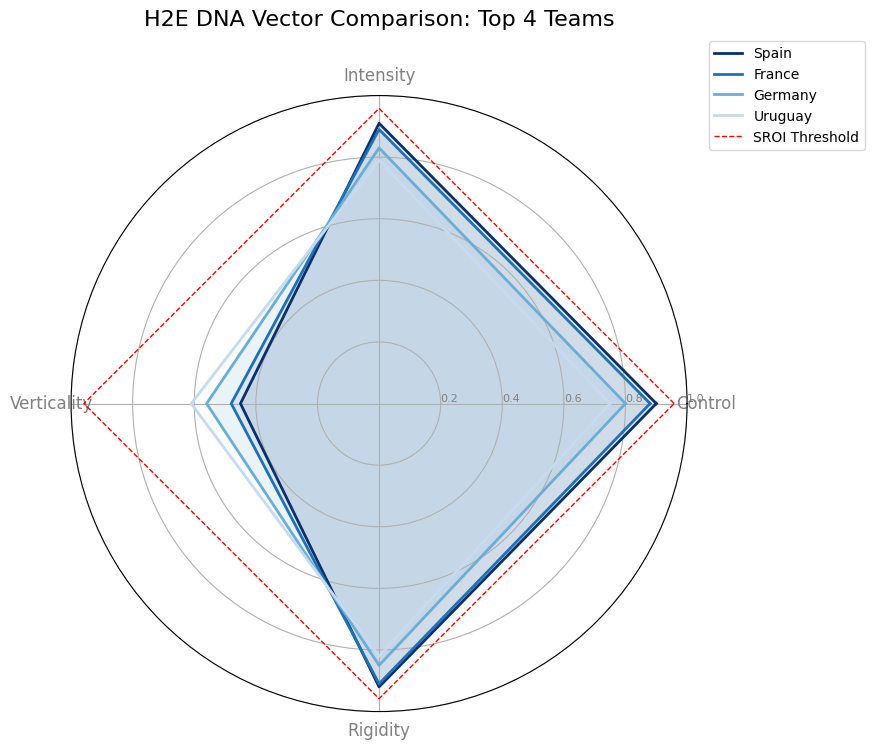

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. DATA PREPARATION
# Categories derived from your H2E NEZ_VAULT
categories = ['Control', 'Intensity', 'Verticality', 'Rigidity']
N = len(categories)

# Team Data from your H2E Dynamic Tournament Summary
team_data = {
    'Spain': [0.90, 0.91, 0.45, 0.92],
    'France': [0.88, 0.89, 0.48, 0.91],
    'Germany': [0.80, 0.83, 0.56, 0.85],
    'Uruguay': [0.75, 0.79, 0.61, 0.82]
}

# 2. RADAR CHART CONFIGURATION
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # Close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# 3. PLOTTING TEAMS
colors = ['#08306b', '#2070b4', '#6aaed6', '#c6dbef']

for (team, values), color in zip(team_data.items(), colors):
    data = values + values[:1]
    ax.plot(angles, data, linewidth=2, linestyle='solid', label=team, color=color)
    ax.fill(angles, data, color=color, alpha=0.1)

# 4. AESTHETICS & GOVERNANCE THRESHOLD
plt.xticks(angles[:-1], categories, color='grey', size=12)
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2","0.4","0.6","0.8","1.0"], color="grey", size=8)
plt.ylim(0, 1)

# Adding your H2E SROI Threshold
ax.plot(angles, [0.9583]*len(angles), color='red', linestyle='--', linewidth=1, label='SROI Threshold')

plt.title('H2E DNA Vector Comparison: Top 4 Teams', size=16, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()